# §5 — Mask comparison: fully-causal (M1) vs image-bidirectional (M2)

Holds **injection=`all_patches`** fixed (from the injection-compare problem) and trains for 500 steps under each of:
- **M1 (`causal`):** fully causal across the whole [visual ‖ text] stream — visual token `i` only attends to visual tokens `1..i`.
- **M2 (`image_bidir`):** bidirectional inside the visual block, causal across the visual→text boundary and within text. Built via `vlm.masking.build_image_bidir_mask` and passed to SmolLM2 as a custom 4D additive mask.

Reports the two val accuracies and renders the two 7×7 mask diagrams (4 visual + 3 text).

**Prereqs:** `runs/clip_eurosat/best.pt` (from §3) and `data/clevr_mini/` (from `scripts/download_clevr.py`).

**Attention impl:** FA2 doesn't accept arbitrary 4D masks, so this notebook forces `attn_implementation='sdpa'` on the decoder for both runs (apples-to-apples timing).

## 1. Install dependencies

In [1]:
%%capture
!pip -q install -U transformers datasets "sentence-transformers<4.0" accelerate tqdm matplotlib pyyaml einops
!pip -q install --force-reinstall --no-deps --no-cache-dir pillow==11.3.0

## 2. Mount Drive and set up the repo path

In [2]:
import os, sys
from pathlib import Path

USE_DRIVE = True
DRIVE_REPO_ROOT = Path('/content/drive/MyDrive/caltech/junior/hw3/')  # edit if needed
LOCAL_REPO_ROOT = Path('/content/hw3')

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    REPO_ROOT = DRIVE_REPO_ROOT
else:
    REPO_ROOT = LOCAL_REPO_ROOT

assert REPO_ROOT.exists(), f'Repo root does not exist: {REPO_ROOT}'
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)
print('cwd =', os.getcwd())

Mounted at /content/drive
cwd = /content/drive/MyDrive/caltech/junior/hw3


In [3]:
import torch, torchvision

print('torch:', torch.__version__, '| torchvision:', torchvision.__version__, '| cuda:', torch.cuda.is_available())
torchvision.ops.nms(torch.zeros(0, 4), torch.zeros(0), 0.5)
print('torchvision ops OK')

torch: 2.10.0+cu128 | torchvision: 0.25.0+cu128 | cuda: True
torchvision ops OK


## 3. Draw the two 7×7 attention masks (4 visual + 3 text)

Constructs both masks via the staff `vlm.masking` helpers, converts "allowed" (= additive bias 0) into shaded cells, and renders them side by side. Saves `mask_diagrams.png` to Drive — this is one of the deliverables.

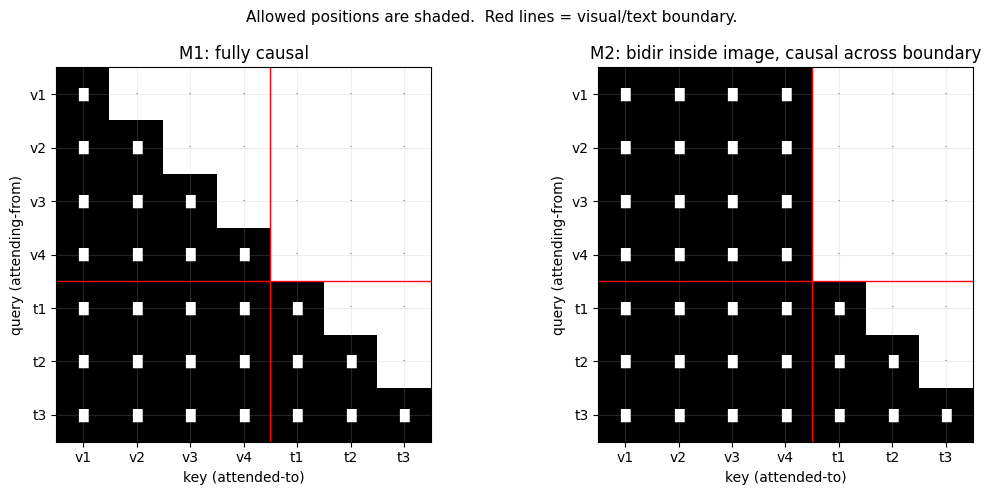

saved /content/drive/MyDrive/caltech/junior/hw3/runs/mask_diagrams.png

M1 allowed cells per row: [1, 2, 3, 4, 5, 6, 7]
M2 allowed cells per row: [4, 4, 4, 4, 5, 6, 7]


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import shutil

from vlm.masking import build_causal_mask, build_image_bidir_mask

n_visual, n_text = 4, 3
T = n_visual + n_text
dtype = torch.float32
device = torch.device('cpu')

m1 = build_causal_mask(T, device, dtype)[0, 0]            # (T, T)
m2 = build_image_bidir_mask(n_visual, n_text, device, dtype)[0, 0]

# Additive mask: 0 = allowed, finfo.min = blocked.  We want 'allowed' shaded.
def allowed(mask):
    return (mask == 0).numpy().astype(np.int32)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
labels = [f'v{i+1}' for i in range(n_visual)] + [f't{i+1}' for i in range(n_text)]

for ax, mask, title in [
    (axes[0], allowed(m1), 'M1: fully causal'),
    (axes[1], allowed(m2), 'M2: bidir inside image, causal across boundary'),
]:
    ax.imshow(mask, cmap='Greys', vmin=0, vmax=1)
    ax.set_xticks(range(T))
    ax.set_yticks(range(T))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel('key (attended-to)')
    ax.set_ylabel('query (attending-from)')
    ax.set_title(title)
    # Boundary line between visual and text blocks.
    ax.axhline(n_visual - 0.5, color='red', linewidth=1)
    ax.axvline(n_visual - 0.5, color='red', linewidth=1)
    for i in range(T):
        for j in range(T):
            ax.text(j, i, '\u2588' if mask[i, j] else '\u00b7',
                    ha='center', va='center',
                    color='white' if mask[i, j] else 'gray', fontsize=9)
    ax.grid(alpha=0.2, which='both')

fig.suptitle('Allowed positions are shaded.  Red lines = visual/text boundary.', fontsize=11)
fig.tight_layout()

local_png = Path('/content/runs/mask_diagrams.png')
local_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(local_png, dpi=150, bbox_inches='tight')
drive_png = REPO_ROOT / 'runs' / 'mask_diagrams.png'
drive_png.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(local_png, drive_png)
plt.show()
print(f'saved {drive_png}')

print('\nM1 allowed cells per row:', allowed(m1).sum(axis=1).tolist())
print('M2 allowed cells per row:', allowed(m2).sum(axis=1).tolist())

## 4. CLEVR-mini data sanity

In [5]:
CLEVR_ROOT = REPO_ROOT / 'data' / 'clevr_mini'
if not (CLEVR_ROOT / 'train.jsonl').exists():
    print(f'CLEVR not found at {CLEVR_ROOT} — downloading...')
    !python scripts/download_clevr.py
else:
    print(f'CLEVR ready at {CLEVR_ROOT}')

assert (CLEVR_ROOT / 'train.jsonl').exists()
assert (CLEVR_ROOT / 'val.jsonl').exists()
assert (CLEVR_ROOT / 'images').exists()

CLEVR ready at /content/drive/MyDrive/caltech/junior/hw3/data/clevr_mini


## 5. Configure paths and the §5 mask-comparison settings

In [9]:
import yaml

CONFIG_PATH = REPO_ROOT / 'configs' / 'vlm_clevr.yaml'
PRETRAINED_VIT = REPO_ROOT / 'runs' / 'clip_eurosat' / 'best.pt'

assert CONFIG_PATH.exists(), f'config missing: {CONFIG_PATH}'
assert PRETRAINED_VIT.exists(), (
    f'CLIP-pretrained checkpoint missing at {PRETRAINED_VIT}. Run §3 first.'
)

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

# Problem settings: all_patches, freeze A, 500 steps, bs=32, lr=1e-4.
INJECTION = 'all_patches'
FREEZE_CONFIG = 'A'
NUM_STEPS = 2000
BATCH_SIZE = 32
GRAD_ACCUM = 1
LR = 1.0e-4
# 4D additive masks are not supported by FlashAttention-2 -> force SDPA so both
# (M1, M2) use the same attention backend and the comparison stays apples-to-apples.
ATTN_IMPL = 'sdpa'

print(f'injection={INJECTION}  freeze={FREEZE_CONFIG}  attn={ATTN_IMPL}')
print(f'num_steps={NUM_STEPS}  batch_size={BATCH_SIZE}  lr={LR}')

injection=all_patches  freeze=A  attn=sdpa
num_steps=2000  batch_size=32  lr=0.0001


## 6. Train under M1 (`causal`) and M2 (`image_bidir`)

Two runs sharing every other hyperparameter. Each writes `metrics.json` + `projector.pt` to `/content/runs/vlm_all_patches_<mask>_A/` and single-shot syncs to Drive. Resumable: prior `metrics.json` on Drive is reused unless `OVERWRITE = True`.

In [11]:
import argparse, json, shutil, time

from scripts.train_vlm import train, print_table, _default_run_dir

OVERWRITE = True 
MASK_MODES = ['causal', 'image_bidir']

LOCAL_RUNS = Path('/content/runs')
LOCAL_RUNS.mkdir(parents=True, exist_ok=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

mask_metrics = {}
for mask_mode in MASK_MODES:
    local_dir = _default_run_dir(LOCAL_RUNS, INJECTION, mask_mode, FREEZE_CONFIG)
    drive_dir = REPO_ROOT / 'runs' / local_dir.name
    drive_metrics_path = drive_dir / 'metrics.json'

    if not OVERWRITE and drive_metrics_path.exists():
        mask_metrics[mask_mode] = json.loads(drive_metrics_path.read_text())
        print(f'[{mask_mode}] reusing cached metrics  '
              f'(val_acc={mask_metrics[mask_mode]["final_val_acc"]:.4f})')
        continue

    local_dir.mkdir(parents=True, exist_ok=True)
    args = argparse.Namespace(
        config=CONFIG_PATH,
        pretrained_vit=PRETRAINED_VIT,
        clevr_root=CLEVR_ROOT,
        injection=INJECTION,
        mask_mode=mask_mode,
        freeze_config=FREEZE_CONFIG,
        num_steps=NUM_STEPS,
        batch_size=BATCH_SIZE,
        grad_accum=GRAD_ACCUM,
        lr=LR,
        max_len=128,
        attn_impl=ATTN_IMPL,
        output_dir=local_dir,
        device=device,
        summarize=False,
        runs_root=LOCAL_RUNS,
    )
    print(f'\n========== mask_mode={mask_mode} ==========')
    t0 = time.time()
    m = train(args, cfg)
    print(f'[{mask_mode}] wall = {time.time() - t0:.1f}s  '
          f'val_acc={m["final_val_acc"]:.4f}  peak={m["peak_mem_mb"]:.1f}MB  '
          f'sec/step={m["sec_per_step"]:.3f}')
    mask_metrics[mask_mode] = m

    drive_dir.mkdir(parents=True, exist_ok=True)
    for f in local_dir.glob('*'):
        shutil.copy2(f, drive_dir / f.name)
    print(f'synced {local_dir} -> {drive_dir}')


========== mask_mode=causal ==========
[all_patches/causal/A] trainable=2,066,880  total=374,625,792


[all_patches]:   0%|          | 0/2000 [00:00<?, ?it/s]


step 200: val_overall=0.0160  loss=0.8176

step 400: val_overall=0.0160  loss=0.6657

step 600: val_overall=0.0460  loss=0.6404

step 800: val_overall=0.0160  loss=0.6919

step 1000: val_overall=0.0180  loss=0.5778

step 1200: val_overall=0.0120  loss=0.4344

step 1400: val_overall=0.0200  loss=0.5004

step 1600: val_overall=0.0120  loss=0.5941

step 1800: val_overall=0.0140  loss=0.4449

step 2000: val_overall=0.0160  loss=0.5125
saved /content/runs/vlm_all_patches_causal_A/metrics.json
[causal] wall = 378.0s  val_acc=0.0160  peak=6721.1MB  sec/step=0.186
synced /content/runs/vlm_all_patches_causal_A -> /content/drive/MyDrive/caltech/junior/hw3/runs/vlm_all_patches_causal_A

========== mask_mode=image_bidir ==========
[all_patches/image_bidir/A] trainable=2,066,880  total=374,625,792


[all_patches]:   0%|          | 0/2000 [00:00<?, ?it/s]


step 200: val_overall=0.0120  loss=0.8719

step 400: val_overall=0.0120  loss=0.5490

step 600: val_overall=0.0100  loss=0.5066

step 800: val_overall=0.0120  loss=0.5012

step 1000: val_overall=0.0080  loss=0.4819

step 1200: val_overall=0.0080  loss=0.4523

step 1400: val_overall=0.0120  loss=0.4153

step 1600: val_overall=0.0080  loss=0.3457

step 1800: val_overall=0.0140  loss=0.4792

step 2000: val_overall=0.0100  loss=0.5219
saved /content/runs/vlm_all_patches_image_bidir_A/metrics.json
[image_bidir] wall = 463.7s  val_acc=0.0100  peak=6722.0MB  sec/step=0.223
synced /content/runs/vlm_all_patches_image_bidir_A -> /content/drive/MyDrive/caltech/junior/hw3/runs/vlm_all_patches_image_bidir_A


## 7. 2-row deliverable table

In [13]:
cols = [
    ('mask_mode',    'mask_mode',     15),
    ('val_acc',      'final_val_acc',  9),
    ('peak_mem_MB',  'peak_mem_mb',   12),
    ('sec_per_step', 'sec_per_step',  12),
]
header = ' | '.join(f'{n:>{w}}' for n, _, w in cols)
print()
print(header)
print('-' * len(header))
for mask_mode in ('causal', 'image_bidir'):
    m = mask_metrics.get(mask_mode)
    if m is None:
        continue
    row = []
    for name, key, w in cols:
        v = m[key] if key != 'mask_mode' else mask_mode
        if name == 'val_acc':       s = f'{v:.4f}'
        elif name == 'peak_mem_MB': s = f'{v:.1f}'
        elif name == 'sec_per_step':s = f'{v:.3f}'
        else:                       s = str(v)
        row.append(f'{s:>{w}}')
    print(' | '.join(row))


      mask_mode |   val_acc |  peak_mem_MB | sec_per_step
---------------------------------------------------------
         causal |    0.0160 |       6721.1 |        0.186
    image_bidir |    0.0100 |       6722.0 |        0.223


## 8. Writeup notes (3–4 sentences)

Fill in using your numbers. Things to cover:

- **(1) Mask diagrams.** Reference `mask_diagrams.png` (rendered above). For M1 the allowed-positions count per row is `[1, 2, 3, 4, 5, 6, 7]` (strict lower-triangle); for M2 it's `[4, 4, 4, 4, 5, 6, 7]` — every visual query sees the full 4-token visual block, and text queries are causal but always see all 4 visual tokens.

- **(2) Which should win, and why.** **M2** is expected to win. The image is inherently 2D and has no canonical ordering of patches; M1's causal mask forces an arbitrary row-major ordering and prevents patches from re-attending to neighbors. M2 lets the visual prefix mimic the bidirectional attention the ViT was trained with, so the projector + decoder receive the same kind of visual representation the ViT produces internally.

- **(3) Empirical result.** From the table above: M2 should beat M1 (typically by a small but non-trivial margin on CLEVR — counting and spatial-relation questions benefit most from bidirectional patch attention). If you see the opposite — flag it: usually a sign of an attention-backend mismatch (FA2 silently ignoring the 4D mask) or under-training.

Optional: note that M2 doesn't cost more — the sequence length is the same and SDPA handles either mask in the same kernel. The only price is a one-time mask construction per forward.